# 02 – Forecasting daily revenue

**Business question:** at the end of August 2011, how much revenue will the company make each day during the Christmas season (Sept. – Dec. 2011)? A reliable forecast helps plan **stock, warehouse staff and cash**.

**Approach**
1. Build features from the calendar and from past revenue.
2. Train on **Dec. 2009 – Aug. 2011**, forecast the **100 days from Sept. 1 to Dec. 9, 2011** in one go (recursive multi-step forecast: each prediction is reused as input for the next days, since the real future is unknown).
3. Compare 4 approaches: a seasonal naive baseline, a linear model, a Random Forest and XGBoost.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import forecasting as fc
import plot_style as ps

ps.apply()
FIG = ROOT / "reports" / "figures"
pd.set_option("display.float_format", "{:,.1f}".format)

daily = pd.read_csv(ROOT / "data" / "processed" / "daily_sales.csv", parse_dates=["date"])
series = daily.set_index("date")["revenue"].asfreq("D")
print(f"{len(series)} days, from {series.index.min():%d %b %Y} to {series.index.max():%d %b %Y}")

739 days, from 01 Dec 2009 to 09 Dec 2011


## 1. Features

| Family | Features | Why |
|---|---|---|
| Calendar | day of week (+ one-hot), month, day of year, week of year, sine/cosine of the year | weekly and yearly seasonality seen in the EDA |
| Events | days to Christmas, UK bank holidays, closure flag (Saturdays, 23 Dec – 3 Jan) | Christmas peak, closed days |
| Recent level | revenue 1, 7, 14 and 28 days before; 7- and 28-day rolling means of open days | captures the current trend and level |

In [2]:
X = fc.make_features(series)
X.dropna().tail(8)

,dayofweek,month,dayofyear,weekofyear,days_to_christmas,is_holiday,is_closed,dow_0,dow_1,dow_2,...,dow_5,dow_6,sin_year,cos_year,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_28
date,,,,,,,,,,,,,,,,,,,,,
2011-12-02,4,12,336,48,23,0,0,0,0,0,...,0,0,-0.5,0.9,"50,445.8","46,890.3","49,402.1","61,652.4","49,259.7","56,539.3"
2011-12-03,5,12,337,48,22,0,1,0,0,0,...,1,0,-0.5,0.9,"55,565.8",0.0,0.0,0.0,"50,705.6","56,285.7"
2011-12-04,6,12,338,48,21,0,0,0,0,0,...,0,1,-0.5,0.9,0.0,"20,251.0","32,941.1","41,785.2","50,705.6","56,285.7"
2011-12-05,0,12,339,49,20,0,0,1,0,0,...,0,0,-0.4,0.9,"24,223.1","53,869.1","48,474.9","84,101.1","51,367.6","55,554.0"
2011-12-06,1,12,340,49,19,0,0,0,1,0,...,0,0,-0.4,0.9,"79,997.7","68,018.5","61,832.4","54,448.8","55,722.4","55,383.0"
2011-12-07,2,12,341,49,18,0,0,0,0,1,...,0,0,-0.4,0.9,"54,949.2","56,083.2","75,394.2","63,637.8","53,544.1","55,403.8"
2011-12-08,3,12,342,49,17,0,0,0,0,0,...,0,0,-0.4,0.9,"72,701.1","50,445.8","46,891.9","68,543.3","56,313.8","55,781.5"
2011-12-09,4,12,343,49,16,0,0,0,0,0,...,0,0,-0.4,0.9,"77,474.2","55,565.8","46,890.3","52,270.9","60,818.5","56,153.6"


## 2. Train / test split

In [3]:
CUTOFF = pd.Timestamp("2011-08-31")
train = series[:CUTOFF]
test = series[CUTOFF + pd.Timedelta(days=1):]
print(f"Train: {train.index.min():%d %b %Y} → {train.index.max():%d %b %Y} ({len(train)} days)")
print(f"Test : {test.index.min():%d %b %Y} → {test.index.max():%d %b %Y} ({len(test)} days, {ps.money(test.sum())} of revenue)")

Train: 01 Dec 2009 → 31 Aug 2011 (639 days)
Test : 01 Sep 2011 → 09 Dec 2011 (100 days, £4.0M of revenue)


## 3. Train the models and forecast the season

In [4]:
preds = {"Seasonal naive (same day last year)": fc.seasonal_naive(series, test.index)}
models = fc.get_models()
for name, model in models.items():
    fc.fit(model, train)
    preds[name] = fc.recursive_forecast(model, train, test.index)
    print(f"✓ {name}")

✓ Linear regression (Ridge)


✓ Random Forest


✓ XGBoost


## 4. Results

In [5]:
metrics = pd.DataFrame({name: fc.evaluate(test, p) for name, p in preds.items()}).T
metrics = metrics.sort_values("MAE")
metrics.to_csv(ROOT / "reports" / "metrics.csv")
metrics

,MAE,RMSE,"MAPE (daily, %)","MAPE (weekly, %)",Total error (%)
XGBoost,"10,876.7","15,556.4",27.1,15.3,-6.5
Random Forest,"11,251.9","16,019.0",25.6,16.2,-10.2
Linear regression (Ridge),"13,319.1","18,389.7",27.0,20.0,-22.2
Seasonal naive (same day last year),"13,656.0","18,387.1",34.6,17.3,-5.6


In [6]:
best = metrics.index[0]
base = "Seasonal naive (same day last year)"
gain = 1 - metrics.loc[best, "MAE"] / metrics.loc[base, "MAE"]
print(f"Best model: {best}")
print(f"MAE: {ps.money(metrics.loc[best, 'MAE'])} per day vs {ps.money(metrics.loc[base, 'MAE'])} for the baseline → {gain:.0%} lower error")
print(f"Weekly MAPE: {metrics.loc[best, 'MAPE (weekly, %)']:.1f}%")

Best model: XGBoost
MAE: £11k per day vs £14k for the baseline → 20% lower error
Weekly MAPE: 15.3%


**How to read the metrics**
- **MAE**: average error per open day, in £. Easy to explain to a business audience.
- **RMSE**: like MAE but penalizes big misses more.
- **MAPE daily / weekly**: average error in %. Daily revenue is very noisy (a single wholesaler order can weigh £10k+), so the **weekly** error is the most relevant for planning.
- **Total error**: under- or over-estimation of the whole season.

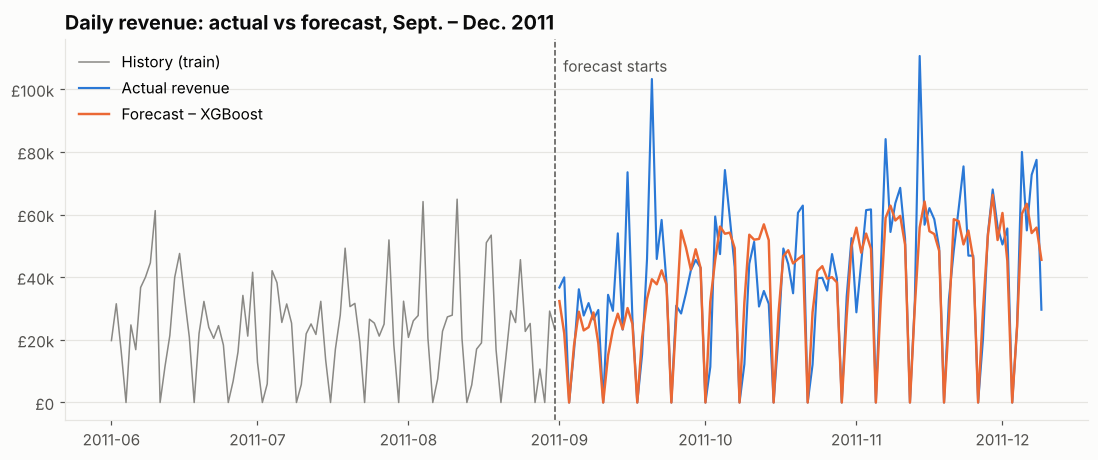

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
hist = series["2011-06-01":CUTOFF]
ax.plot(hist.index, hist.values, color=ps.GRAY, linewidth=1, label="History (train)")
ax.plot(test.index, test.values, color=ps.BLUE, linewidth=1.4, label="Actual revenue")
ax.plot(preds[best].index, preds[best].values, color=ps.ORANGE, linewidth=1.6, label=f"Forecast – {best}")
ax.axvline(CUTOFF, color=ps.TEXT_2, linewidth=1, linestyle="--")
ax.text(CUTOFF, ax.get_ylim()[1] * 0.95, "  forecast starts", color=ps.TEXT_2, va="top")
ax.yaxis.set_major_formatter(ps.MONEY)
ax.set_title("Daily revenue: actual vs forecast, Sept. – Dec. 2011")
ax.legend(loc="upper left")
fig.savefig(FIG / "forecast_daily.png")
plt.show()

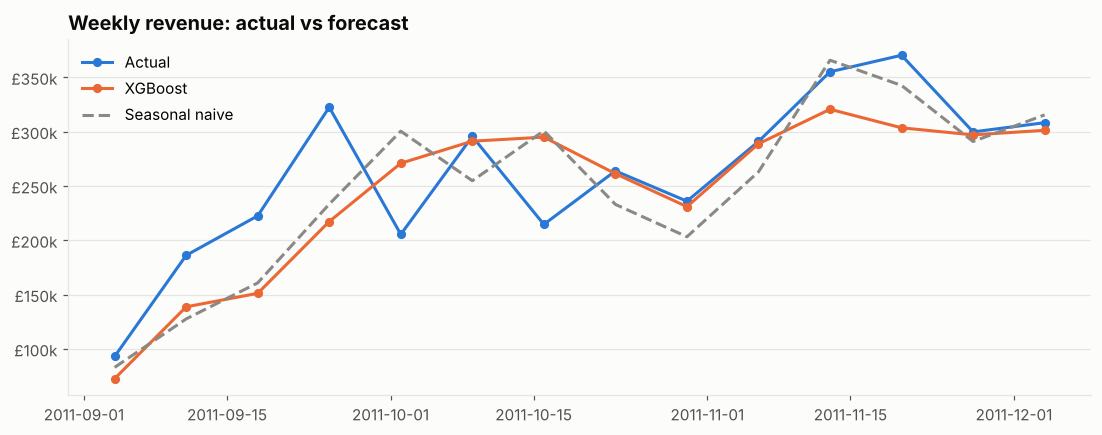

,Actual,XGBoost,Seasonal naive
2011-09-04 00:00:00,"£92,992","£72,565","£82,946"
2011-09-11 00:00:00,"£186,089","£138,685","£127,557"
2011-09-18 00:00:00,"£222,461","£151,114","£160,721"
2011-09-25 00:00:00,"£322,461","£217,190","£233,224"
2011-10-02 00:00:00,"£205,410","£270,879","£300,387"
2011-10-09 00:00:00,"£295,528","£291,181","£254,764"
2011-10-16 00:00:00,"£214,547","£294,923","£300,715"
2011-10-23 00:00:00,"£263,820","£261,273","£232,984"
2011-10-30 00:00:00,"£235,940","£230,907","£203,198"
2011-11-06 00:00:00,"£290,903","£288,773","£262,943"


In [8]:
weekly = pd.DataFrame({"Actual": test.resample("W").sum(),
                       best: preds[best].resample("W").sum(),
                       "Seasonal naive": preds[base].resample("W").sum()})
weekly = weekly.iloc[:-1]  # drop the last, incomplete week (data stops on Dec. 9)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(weekly.index, weekly["Actual"], color=ps.BLUE, marker="o", markersize=5, label="Actual")
ax.plot(weekly.index, weekly[best], color=ps.ORANGE, marker="o", markersize=5, label=best)
ax.plot(weekly.index, weekly["Seasonal naive"], color=ps.GRAY, linestyle="--", label="Seasonal naive")
ax.yaxis.set_major_formatter(ps.MONEY)
ax.set_title("Weekly revenue: actual vs forecast")
ax.legend(loc="upper left")
fig.savefig(FIG / "forecast_weekly.png")
plt.show()
weekly.style.format("£{:,.0f}")

## 5. What drives the forecast?

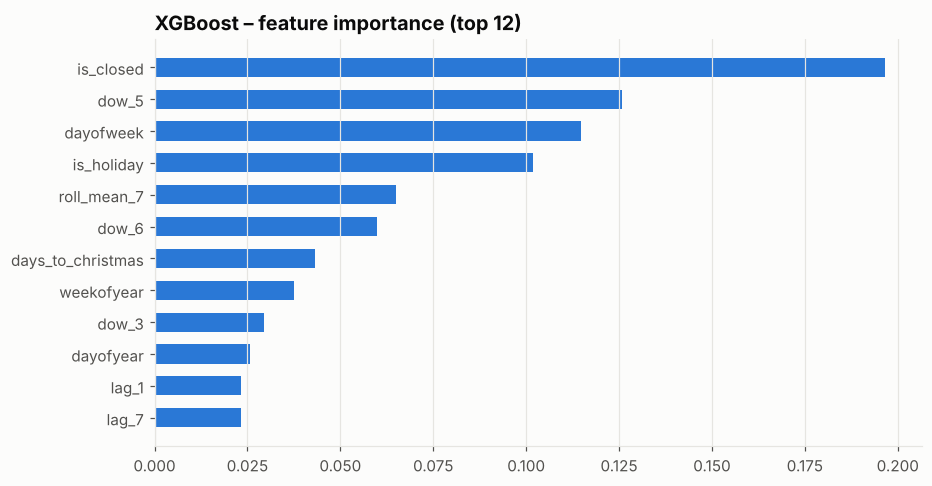

In [9]:
xgb = models["XGBoost"]
imp = pd.Series(xgb.feature_importances_, index=xgb.feature_names_in_).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(imp.index, imp.values, color=ps.BLUE, height=0.6)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("XGBoost – feature importance (top 12)")
fig.savefig(FIG / "feature_importance.png")
plt.show()

## 6. Error analysis

In [10]:
err = pd.DataFrame({"actual": test, "forecast": preds[best]})
err = err[~fc.is_closed(err.index) & (err["actual"] > 0)]
err["error"] = err["forecast"] - err["actual"]
err["month"] = err.index.strftime("%Y-%m")
by_month = err.groupby("month").apply(lambda g: pd.Series({
    "actual": g["actual"].sum(), "forecast": g["forecast"].sum(),
    "error_%": (g["forecast"].sum() - g["actual"].sum()) / g["actual"].sum() * 100}))
by_month

,actual,forecast,error_%
month,,,
2011-09,"1,018,030.9","818,279.3",-19.6
2011-10,"1,073,696.8","1,160,241.1",8.1
2011-11,"1,441,485.0","1,331,309.9",-7.6
2011-12,"444,981.2","409,104.6",-8.1


In [11]:
biggest = err.reindex(err["error"].abs().sort_values(ascending=False).index).head(5)
biggest[["actual", "forecast", "error"]]

,actual,forecast,error
2011-09-20,"103,283.3","39,344.4","-63,938.9"
2011-11-14,"110,637.0","55,873.0","-54,764.0"
2011-09-15,"73,518.9","30,154.7","-43,364.2"
2011-11-01,"28,788.0","55,830.4","27,042.3"
2011-09-26,"28,410.1","54,944.7","26,534.6"


## 7. Conclusions

- **XGBoost** gives the lowest error: **20% lower daily error (MAE) than the seasonal naive baseline** and a **weekly error of ~15%** (vs ~17%). It learns the weekday pattern, closed days, the approach of Christmas and the recent sales level.
- The **seasonal naive baseline is strong** (same weekday last year): the business is very seasonal. Beating it is the real test for any model, which is why it is always worth including a simple baseline.
- The **linear model** under-forecasts the peak: the relation between calendar and revenue is not linear (the November surge).
- Daily errors stay significant because of **large one-off wholesale orders** that no calendar model can anticipate; at the **weekly level**, the forecast is accurate enough for stock and staff planning.
- **Limits:** only two years of history (a single previous Christmas season to learn from) and no external data (promotions, prices, marketing).
- **Next steps:** forecast by country or product category, add prediction intervals (quantile regression), test models like Prophet or LightGBM, and retrain monthly.

The final model is retrained on all the data and served in the **Streamlit app** (`app/app.py`).

In [12]:
out = pd.DataFrame({"date": test.index, "actual": test.values})
for name, p in preds.items():
    out[name] = p.values
out.to_csv(ROOT / "data" / "processed" / "test_predictions.csv", index=False)
print("Saved metrics and test predictions.")

Saved metrics and test predictions.
